In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
import kymatio
import os
import glob
import math
import scipy
import ot
from kymatio.numpy import Scattering1D
import matplotlib.ticker as ticker
from ST import *
from PS import compute_flux_power_spectrum
from statistical_distance import *

In [2]:
#loading redshift2 data
optical_depth_z2 = np.load('hydrogen_redshift234_tau/optical_depth_z2.npy')
flux_z2 = np.exp(-optical_depth_z2)

nspectra_z2 = optical_depth_z2.shape[0]
print('number of spectra:', flux_z2.shape[0], 'length of spectra:',  flux_z2.shape[1])

number of spectra: 2750 length of spectra: 13559


In [3]:
#loading redshift3 data
optical_depth_z3 = np.load('hydrogen_redshift234_tau/optical_depth_z3.npy')
flux_z3 = np.exp(-optical_depth_z3)

nspectra_z3 = optical_depth_z3.shape[0]
print('number of spectra:', flux_z3.shape[0], 'length of spectra:',  flux_z3.shape[1])

number of spectra: 4500 length of spectra: 15300


In [4]:
#load redshift 4 data
optical_depth_z4 = np.load('hydrogen_redshift234_tau/optical_depth_z4.npy')
flux_z4 = np.exp(-optical_depth_z4)


nspectra_z4 = optical_depth_z4.shape[0]
print('number of spectra:', flux_z4.shape[0], 'length of spectra:',  flux_z4.shape[1])

number of spectra: 450 length of spectra: 16962


In [5]:
#using the same J for all lines
J = math.floor(np.log2(flux_z2.shape[1]))
print(J)

13


In [ ]:
#scattering transform on redshift 2 spectra
coefficients_z2, meta_z2 = flux_scattering_transform(flux_z2, J)
coefficients_z2 = coefficients_z2.mean(axis=2)
print(coefficients_z2.shape)

(2750, 103)


In [ ]:
#scattering transform on redshift 3 spectra
coefficients_z3, meta_z3 = flux_scattering_transform(flux_z3, J)
coefficients_z3 = coefficients_z3.mean(axis=2)
print(coefficients_z3.shape)

(4500, 103)


In [ ]:
#scattering transform on redshift 4 spectra
coefficients_z4, meta_z4 = flux_scattering_transform(flux_z4, J)
coefficients_z4 = coefficients_z4.mean(axis=2)
print(coefficients_z4.shape)

(450, 103)


In [29]:
#normalization, calculating mean and standard deviation
S1_z2, S2_z2 = get_normalized_coefficients(coefficients_z2, meta_z2)
S1_z2_mean = np.mean(S1_z2['S1'], axis=0)
S1_z2_std = np.std(S1_z2['S1'], axis=0)
S2_z2_mean = [np.mean(S2_z2['S2'][f'{j}'], axis=0) for j in range(len(S2_z2['S2']))]
S2_z2_std = [np.std(S2_z2['S2'][f'{j}'], axis=0) for j in range(len(S2_z2['S2']))]

NameError: name 'get_normalized_coefficients' is not defined

In [10]:
S1_z3, S2_z3 = get_normalized_S1_S2(coefficients_z3, meta_z3)
S1_z3_mean = np.mean(S1_z3['S1'], axis=0)
S1_z3_std = np.std(S1_z3['S1'], axis=0)
S2_z3_mean = [np.mean(S2_z3['S2'][f'{j}'], axis=0) for j in range(len(S2_z3['S2']))]
S2_z3_std = [np.std(S2_z3['S2'][f'{j}'], axis=0) for j in range(len(S2_z3['S2']))]

In [11]:
S1_z4, S2_z4 = get_normalized_S1_S2(coefficients_z4, meta_z4)
S1_z4_mean = np.mean(S1_z4['S1'], axis=0)
S1_z4_std = np.std(S1_z4['S1'], axis=0)
S2_z4_mean = [np.mean(S2_z4['S2'][f'{j}'], axis=0) for j in range(len(S2_z4['S2']))]
S2_z4_std = [np.std(S2_z4['S2'][f'{j}'], axis=0) for j in range(len(S2_z4['S2']))]

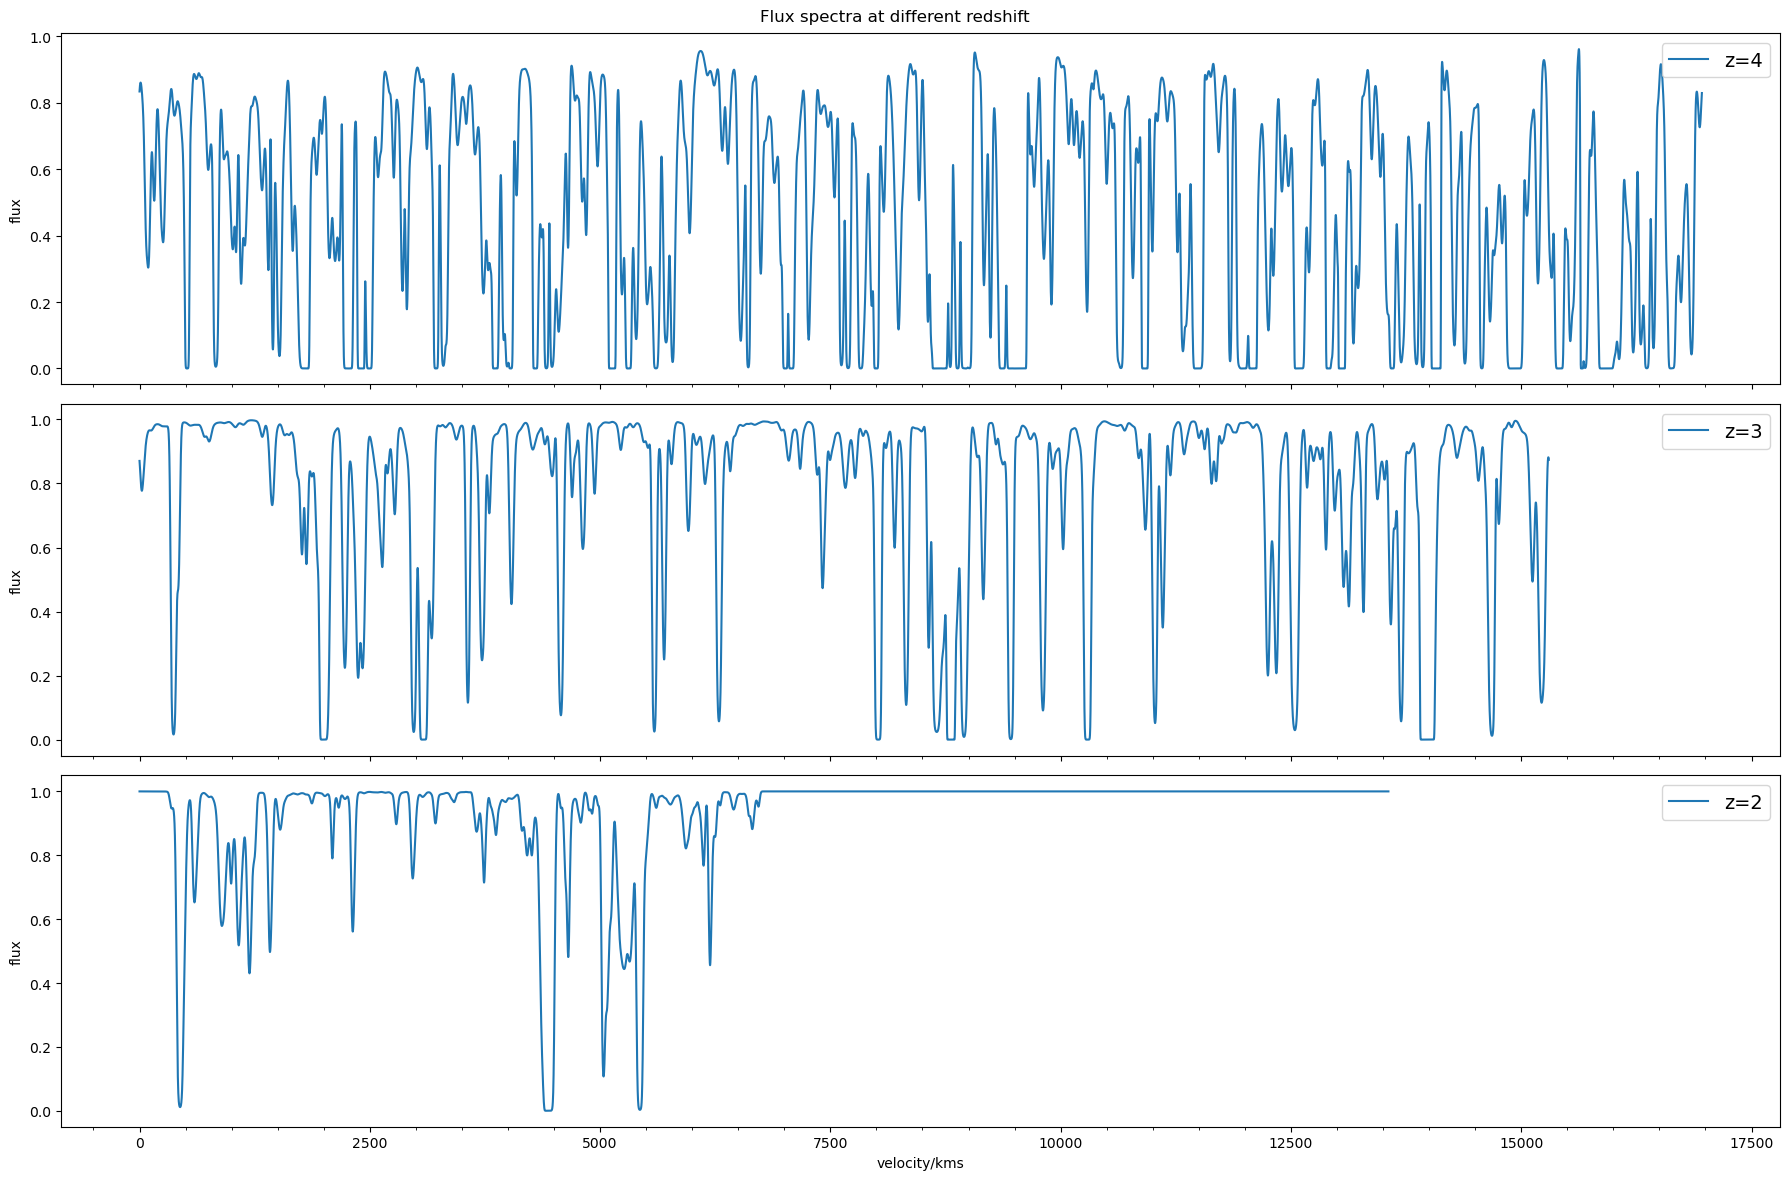

In [12]:
#plot redshift 4 spectra
n = 100
fig, axs = plt.subplots(3, 1, figsize=(18, 12),
                        sharex=True)

axs[0].plot(flux_z4[n], label='z=4')
axs[1].plot(flux_z3[n], label='z=3')
axs[2].plot(flux_z2[n], label='z=2')

for ax in axs:
    ax.set_ylabel('flux')
    ax.legend(loc='upper right', fontsize=14)
    
axs[2].set_xlabel('velocity/kms')
axs[2].xaxis.set_minor_locator(ticker.MultipleLocator(500))
fig.suptitle('Flux spectra at different redshift')
fig.tight_layout()

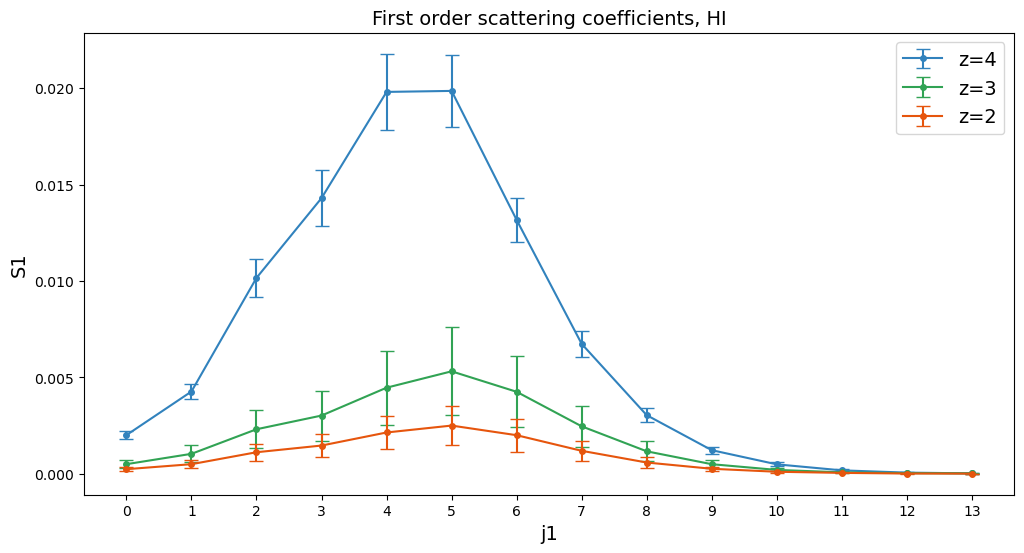

In [13]:
#plot the first order coefficients
fig, axs = plt.subplots(1, figsize=(12, 6))
j1_z4 = np.array(list(S1_z4['j1'].flatten()))[:, 0]
j1_z3 = np.array(list(S1_z3['j1'].flatten()))[:, 0]
j1_z2 = np.array(list(S1_z2['j1'].flatten()))[:, 0]
colors = ['#3182BD', '#31A354', '#E6550D'] 
axs.errorbar(j1_z4, S1_z4_mean, S1_z4_std, fmt='-o', label='z=4', markersize=4, capsize=5, color=colors[0])
axs.errorbar(j1_z3, S1_z3_mean, S1_z3_std, fmt='-o', label='z=3', markersize=4, capsize=5, color=colors[1])
axs.errorbar(j1_z2, S1_z2_mean, S1_z2_std, fmt='-o', label='z=2', markersize=4, capsize=5, color=colors[2])
axs.set_title('First order scattering coefficients, HI', fontsize=14)
axs.set_xticks(j1_z4)
axs.set_xlabel('j1', fontsize=14)
axs.set_ylabel('S1', fontsize=14)
axs.legend(fontsize=14)

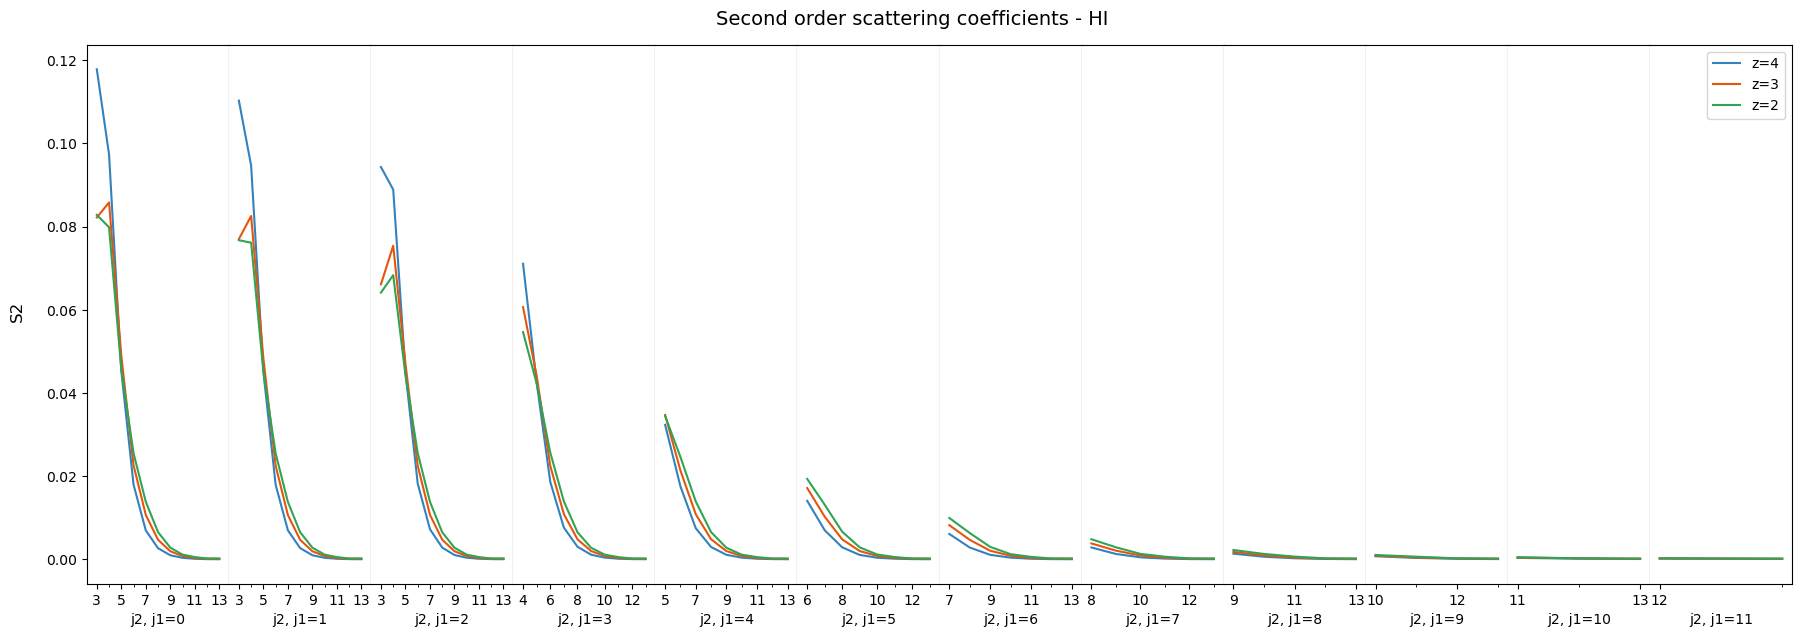

In [14]:
#plot the second order scattering 
fig, axes = plt.subplots(1, len(S2_z4_mean[:-1]), figsize=(22, 7), sharey=True)
fig.subplots_adjust(wspace=0.0) 
fig.suptitle('Second order scattering coefficients - HI', y=0.93, fontsize=14)
fig.supylabel('S2', x=0.09)

for j, (ax, s2_z4, s2_z3, s2_z2) in enumerate(zip(axes, S2_z4_mean, S2_z3_mean, S2_z2_mean)):
    j2_labels = [e[1] for e in S2_z4['j1_j2'][j]]
    ax.plot(s2_z4, label='z=4', color=colors[0])
    ax.plot(s2_z3, label='z=3', color=colors[2])
    ax.plot(s2_z2, label='z=2', color=colors[1])
    ax.set_xlabel(f'j2, j1={j}')
    ax.set_xticks(range(0, len(s2_z4), 2))
    ax.set_xticklabels(j2_labels[::2])
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(1))
    ax.margins(x=0.08)

    if ax != axes[0]:
        ax.spines['left'].set_visible(False)
        ax.tick_params(left=False)
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(0.9, 0.88))


In [15]:
ps_z4 = compute_flux_power_spectrum(flux_z4[:, :flux_z2.shape[1]], 1)
ps_z3 = compute_flux_power_spectrum(flux_z3[:, :flux_z2.shape[1]], 1)
ps_z2 = compute_flux_power_spectrum(flux_z2, 1)

ps_z4_mean = ps_z4.mean(axis=0)
ps_z3_mean = ps_z3.mean(axis=0)
ps_z2_mean = ps_z2.mean(axis=0)

In [16]:
N_z2 = flux_z2.shape[1]
k_z2 = np.fft.fftfreq(N_z2, d=1)

Text(0.5, 0.92, 'Flux power spectrum at different redshift')

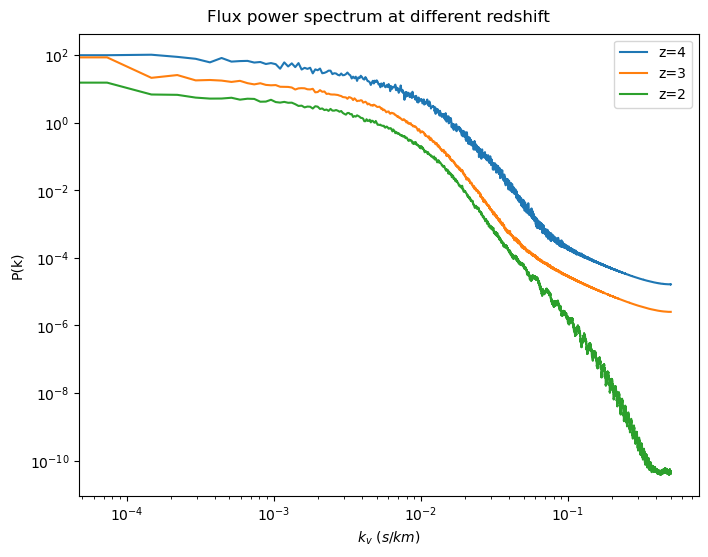

In [17]:
fig, ax = plt.subplots(1, figsize=(8, 6))
ax.loglog(k_z2[:N_z2//2], ps_z4_mean[:N_z2//2], label='z=4')
ax.loglog(k_z2[:N_z2//2], ps_z3_mean[:N_z2//2], label='z=3')
ax.loglog(k_z2[:N_z2//2], ps_z2_mean[:N_z2//2], label='z=2')
ax.set_xlabel('$k_{v}$ $(s/km)$')
ax.set_ylabel('P(k)')
ax.legend()
fig.suptitle('Flux power spectrum at different redshift',x=0.5, y=0.92)

In [18]:
#normalize statistics
ps_z4_normalized = statistics_normalizaiton(ps_z4)
ps_z3_normalized = statistics_normalizaiton(ps_z3)
ps_z2_normalized = statistics_normalizaiton(ps_z2)

ps_z4_normalized_mean = ps_z4_normalized.mean(axis=0)
ps_z3_normalized_mean = ps_z3_normalized.mean(axis=0)
ps_z2_normalized_mean = ps_z2_normalized.mean(axis=0)

In [19]:
S1_z4_normalized = statistics_normalizaiton(S1_z4['S1'])
S1_z3_normalized = statistics_normalizaiton(S1_z3['S1'])
S1_z2_normalized = statistics_normalizaiton(S1_z2['S1'])

S1_z4_normalized_mean = S1_z4_normalized.mean(axis=0)
S1_z3_normalized_mean = S1_z3_normalized.mean(axis=0)
S1_z2_normalized_mean = S1_z2_normalized.mean(axis=0)

In [20]:
ps_z4_normalized_mean

array([0.11077338, 0.21605053, 0.21287754, ..., 0.28574151, 0.21287754,
       0.21605053], shape=(13559,))

In [25]:
PS_distance_z43 = compute_mahalanobis_distance(ps_z4_normalized[:, :N_z2//2], ps_z4_normalized_mean[:N_z2//2], ps_z3_normalized[:, :N_z2//2], ps_z3_normalized_mean[:N_z2//2])
PS_distance_z32 = compute_mahalanobis_distance(ps_z3_normalized, ps_z3_normalized_mean, ps_z2_normalized, ps_z2_normalized_mean)

S1_distance_z43 = compute_mahalanobis_distance(S1_z4_normalized, S1_z4_normalized_mean, S1_z3_normalized, S1_z3_normalized_mean)
S1_distance_z32 = compute_mahalanobis_distance(S1_z3_normalized, S1_z3_normalized_mean, S1_z2_normalized, S1_z2_normalized_mean)

In [26]:
PS_distance_z43_normalized = PS_distance_z43 / np.sqrt(N_z2//2)
PS_distance_z32_normalized = PS_distance_z32 / np.sqrt(N_z2)

S1_distance_z43_normalized = S1_distance_z43 / np.sqrt(J+1)
S1_distance_z32_normalized = S1_distance_z32 / np.sqrt(J+1)

In [27]:
print(S1_distance_z43_normalized, PS_distance_z43_normalized)
print(S1_distance_z32_normalized, PS_distance_z32_normalized)

print('comparing normalized S1 to unnormalized power spectrum????')
#normalize the distribution of each redshift data or normalize redshift 2 and 3 or 3 and 4 together?

0.7327051544036847 0.05741861441493061
0.4548114509935711 0.1587633731101202
comparing normalized S1 to unnormalized power spectrum????


In [28]:
PS_z4_std = np.std(ps_z4_normalized[:, :N_z3//2], axis=0)
PS_z3_std = np.std(ps_z3_normalized[:, :N_z3//2], axis=0)
S1_z4_std = np.std(S1_z4_normalized, axis=0)
S1_z3_std = np.std(S1_z3_normalized, axis=0)

wst_distance_PS_z43 = ot.sliced_wasserstein_distance(ps_z4_normalized[:, :N_z3//2]/PS_z4_std, ps_z3_normalized[:, :N_z3//2]/PS_z3_std, n_projections=N_z3//2, seed=42)
wst_distance_ST_z43 = ot.sliced_wasserstein_distance(S1_z4_normalized/S1_z4_std, S1_z3_normalized/S1_z3_std, n_projections=14, seed=42)

NameError: name 'N_z3' is not defined

In [ ]:
print(wst_distance_PS_z43)
print(wst_distance_ST_z43)